# Semana 9 - Ejercicio 1: Árboles de Clasificación y Regresión

**Materia:** Minería de Datos  
**Tema:** Árboles de Decisión  
**Estudiante:** Sara Valenzuela  

## Objetivo
Comparar el uso de un árbol de decisión para clasificación y para regresión utilizando un dataset de precios de viviendas.

In [1]:
# Importación de librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Carga del dataset de precios de viviendas
df = pd.read_csv("/house_prices.csv")

# Visualización de las primeras filas
df.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [6]:
# Información general del dataset
df.info()

# Estadísticas descriptivas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [7]:
# Crear variable categórica basada en la mediana del precio
mediana_precio = df["Price"].median()

df["Categoria_Precio"] = np.where(
    df["Price"] >= mediana_precio,
    "Cara",
    "Barata"
)

df[["Price", "Categoria_Precio"]].head()

,Price,Categoria_Precio
0,114300,Barata
1,114200,Barata
2,114800,Barata
3,94700,Barata
4,119800,Barata


In [8]:
# Convertir variables categóricas a numéricas
df_clasificacion = pd.get_dummies(
    df,
    columns=["Brick", "Neighborhood"],
    drop_first=True
)

df_clasificacion.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Categoria_Precio,Brick_Yes,Neighborhood_North,Neighborhood_West
0,1,114300,1790,2,2,2,Barata,False,False,False
1,2,114200,2030,4,2,3,Barata,False,False,False
2,3,114800,1740,3,2,1,Barata,False,False,False
3,4,94700,1980,3,2,3,Barata,False,False,False
4,5,119800,2130,3,3,3,Barata,False,False,False


## Preparación de los datos

Se creó una nueva variable denominada **Categoria_Precio**, que clasifica las viviendas como "Cara" o "Barata" utilizando la mediana del precio como punto de corte.

Además, las variables categóricas **Brick** y **Neighborhood** fueron transformadas a formato numérico mediante codificación dummy para permitir su utilización en los modelos de aprendizaje automático.

In [9]:
# Variables predictoras
X = df_clasificacion.drop(columns=["Price", "Categoria_Precio"])

# Variable objetivo
y = df_clasificacion["Categoria_Precio"]

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (102, 8)
Datos de prueba: (26, 8)


## División de los datos

El conjunto de datos fue dividido en entrenamiento (80%) y prueba (20%).

Los datos de entrenamiento se utilizan para construir el modelo, mientras que los datos de prueba permiten evaluar su capacidad de generalización sobre datos no vistos.

In [10]:
# Crear y entrenar el árbol de clasificación

tree_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

tree_clf.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [11]:
# Predicciones

y_pred = tree_clf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

Accuracy: 0.9230769230769231


In [12]:
# Matriz de confusión

print(confusion_matrix(y_test, y_pred))

# Reporte de clasificación

print(classification_report(y_test, y_pred))

[[12  1]
 [ 1 12]]
              precision    recall  f1-score   support

      Barata       0.92      0.92      0.92        13
        Cara       0.92      0.92      0.92        13

    accuracy                           0.92        26
   macro avg       0.92      0.92      0.92        26
weighted avg       0.92      0.92      0.92        26



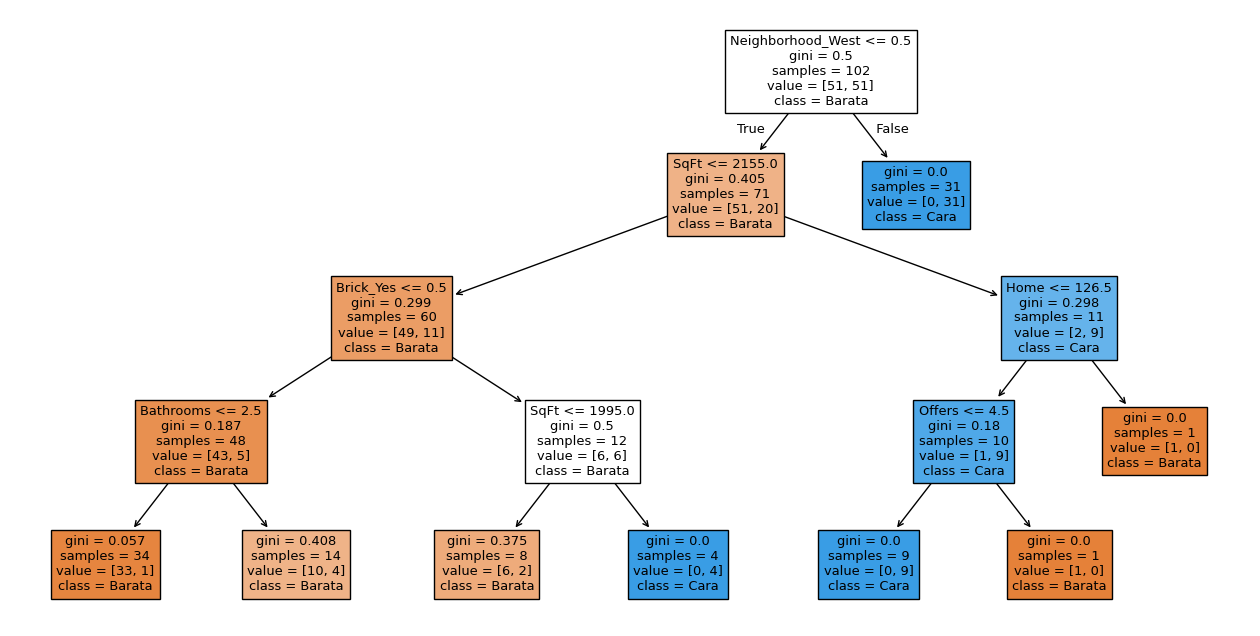

In [13]:
plt.figure(figsize=(16,8))

plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=["Barata", "Cara"],
    filled=True
)

plt.show()

## Conclusión del Árbol de Clasificación

Se entrenó un árbol de decisión para clasificar viviendas en las categorías "Barata" y "Cara" utilizando variables relacionadas con las características de cada propiedad.

El modelo obtuvo una precisión de 92,31% sobre el conjunto de prueba, lo que indica una buena capacidad para identificar correctamente ambas categorías.

La matriz de confusión mostró únicamente dos clasificaciones incorrectas, mientras que las métricas Precision, Recall y F1-Score alcanzaron valores de 0,92 para ambas clases. Esto demuestra que el modelo presenta un desempeño equilibrado y una adecuada capacidad de generalización.

Los resultados obtenidos evidencian que los árboles de decisión constituyen una herramienta efectiva para problemas de clasificación debido a su facilidad de interpretación y capacidad para identificar patrones presentes en los datos.

# Árbol de Regresión

En esta parte se utiliza un árbol de decisión de regresión para predecir el precio exacto de una vivienda a partir de sus características.

In [14]:
# Variables predictoras para regresión
X_reg = df_clasificacion.drop(columns=["Price", "Categoria_Precio"])

# Variable objetivo numérica
y_reg = df_clasificacion["Price"]

# División entrenamiento y prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train_reg.shape)
print("Datos de prueba:", X_test_reg.shape)

Datos de entrenamiento: (102, 8)
Datos de prueba: (26, 8)


In [15]:
# Crear y entrenar el árbol de regresión
tree_reg = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_reg.fit(X_train_reg, y_train_reg)

print("Modelo de regresión entrenado correctamente")

Modelo de regresión entrenado correctamente


In [16]:
# Predicciones del modelo de regresión
y_pred_reg = tree_reg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 10884.935481185481
MSE: 227408352.53825915
RMSE: 15080.064739193236
R2: 0.6141690183149361


In [17]:
# Comparación entre valores reales y predichos
comparacion = pd.DataFrame({
    "Precio_Real": y_test_reg.values,
    "Precio_Predicho": y_pred_reg
})

comparacion.head(10)

,Precio_Real,Precio_Predicho
0,125700,111300.000000
1,106600,111300.000000
2,167200,165666.666667
3,112300,125590.909091
4,145500,148025.000000
5,140900,145985.714286
6,165600,148025.000000
7,82300,104420.833333
8,184300,183700.000000
9,137000,148025.000000


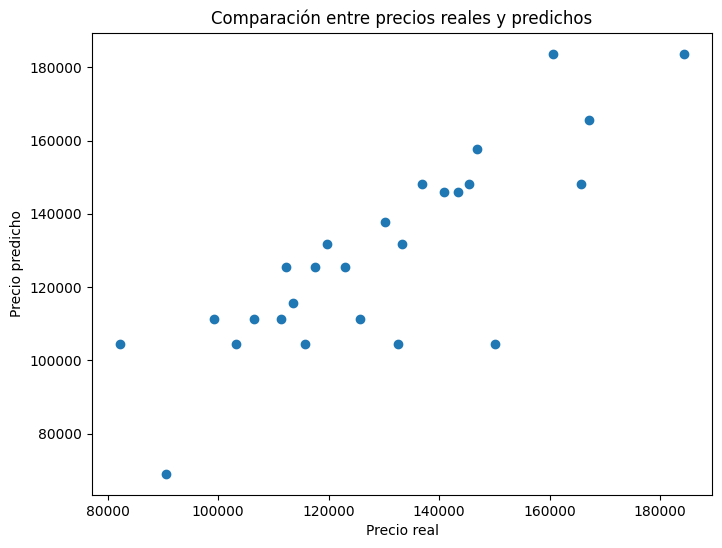

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Comparación entre precios reales y predichos")
plt.show()

## Conclusión del Árbol de Regresión

Se implementó un árbol de decisión de regresión para estimar el precio exacto de las viviendas utilizando variables relacionadas con sus características físicas y ubicación.

El modelo obtuvo un coeficiente de determinación R² de 0,614, indicando que logra explicar aproximadamente el 61,4% de la variabilidad observada en los precios de las propiedades.

Por otro lado, el Error Absoluto Medio (MAE) fue de 10.884 dólares, mientras que el Error Cuadrático Medio Raíz (RMSE) alcanzó 15.081 dólares. Estos resultados muestran que el modelo presenta una capacidad predictiva aceptable, aunque todavía existen diferencias entre los valores reales y los estimados.

Los árboles de regresión permiten modelar relaciones no lineales entre variables y constituyen una alternativa útil para problemas de predicción de valores continuos.

# Comparación entre Clasificación y Regresión

En este ejercicio se aplicaron árboles de decisión para resolver dos tipos diferentes de problemas.

En el caso de clasificación, el modelo logró identificar correctamente viviendas "Baratas" y "Caras", alcanzando una precisión de 92,31%, lo que demuestra una alta capacidad de discriminación entre categorías.

Por otro lado, el árbol de regresión fue utilizado para estimar el precio exacto de las viviendas, obteniendo un R² de 0,614. Aunque la predicción numérica es más compleja, el modelo logró capturar una parte importante de la variabilidad de los precios.

Estos resultados permiten observar la diferencia entre ambos enfoques: mientras la clasificación predice categorías discretas, la regresión estima valores continuos. Ambos métodos utilizan la misma estructura de árbol de decisión, pero se aplican a problemas distintos dentro de la minería de datos.